In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip '/content/drive/MyDrive/DL_PROJECT/dataset_split_01.zip' -d '/content'

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset_split_01/train/omelette/2267564.jpg  
  inflating: /content/dataset_split_01/train/omelette/849447.jpg  
  inflating: /content/dataset_split_01/train/omelette/2047977.jpg  
  inflating: /content/dataset_split_01/train/omelette/2330281.jpg  
  inflating: /content/dataset_split_01/train/omelette/812242.jpg  
  inflating: /content/dataset_split_01/train/omelette/2143126.jpg  
  inflating: /content/dataset_split_01/train/omelette/599895.jpg  
  inflating: /content/dataset_split_01/train/omelette/752881.jpg  
  inflating: /content/dataset_split_01/train/omelette/3088018.jpg  
  inflating: /content/dataset_split_01/train/omelette/2872698.jpg  
  inflating: /content/dataset_split_01/train/omelette/1316172.jpg  
  inflating: /content/dataset_split_01/train/omelette/2174627.jpg  
  inflating: /content/dataset_split_01/train/omelette/2102413.jpg  
  inflating: /content/dataset_split_01/train/omelette/3847051.jpg  
 

In [4]:
%cd '/content/dataset_split_01'

/content/dataset_split_01


In [5]:
dataset_path = '/content/dataset_split_01'
training_data_path = '/content/dataset_split_01/train'
val_data_path = '/content/dataset_split_01/val'

In [6]:
#reading the data in train and val

import os
len(os.listdir(dataset_path+'/train/Baked Potato')) # trian data


240

In [8]:
len(os.listdir(dataset_path+'/val/Baked Potato')) # val data

60

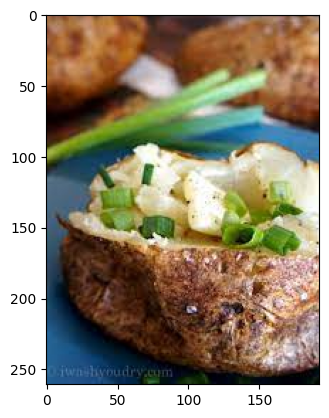

In [9]:
# checking the images in dataset train

import numpy as np
import matplotlib.pyplot as plt

image = plt.imread('/content/dataset_split_01/train/Baked Potato/Baked Potato-Train (1000).jpeg')
plt.imshow(image)
plt.show()

In [10]:
# define the rules by ImageDataGenerator

import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
training_data_preprocess = ImageDataGenerator(1/255, rotation_range=0.2, shear_range= 0.2, horizontal_flip=True)
val_data_preprocess = ImageDataGenerator(1/255, horizontal_flip=True)

In [12]:
classes = [
    folder for folder in os.listdir(training_data_path)
    if os.path.isdir(os.path.join(training_data_path, folder))
]

print(classes)

labels = classes

['Fries', 'ice_cream', 'fried_rice', 'apple_pie', 'sushi', 'momos', 'dal_makhani', 'Donut', 'chicken_curry', 'omelette', 'Taquito', 'dhokla', 'masala_dosa', 'butter_naan', 'jalebi', 'pakode', 'Hot Dog', 'cheesecake', 'chai', 'kaathi_rolls', 'samosa', 'Taco', 'Crispy Chicken', 'chole_bhature', 'kulfi', 'burger', 'paani_puri', 'pav_bhaji', 'Sandwich', 'kadai_paneer', 'chapati', 'Baked Potato', 'idli', 'pizza']


In [13]:
#Applying the rules

Final_Training_Data = training_data_preprocess.flow_from_directory(training_data_path,target_size=(224,224),
                                                                   class_mode='categorical',
                                                                   batch_size=32,
                                                                   classes=labels,
                                                                   color_mode='rgb')


Final_Val_Data = val_data_preprocess.flow_from_directory(val_data_path,
                                                   target_size=(224,224),
                                                   class_mode='categorical',
                                                   batch_size=32,
                                                   classes=labels,
                                                   color_mode='rgb')

Found 7779 images belonging to 34 classes.
Found 1947 images belonging to 34 classes.


In [14]:
from tensorflow.keras.applications import VGG16



In [15]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense,Activation, MaxPooling2D, Conv2D, Flatten
from tensorflow.keras.activations import relu, softmax, sigmoid

In [16]:
vgg16_obj = VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False) #rgba

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [17]:
for i in vgg16_obj.layers:
  i.trainable = False

In [18]:
one_d_val = Flatten()(vgg16_obj.output)

In [19]:
one_d_val

<KerasTensor shape=(None, 25088), dtype=float32, sparse=False, ragged=False, name=keras_tensor_19>

In [20]:
h1_out = Dense(units=128, kernel_initializer='he_uniform', activation=relu)(one_d_val)
h2_out = Dense(units=64, kernel_initializer='he_uniform', activation=relu)(h1_out)
h3_out = Dense(units=32, kernel_initializer='he_uniform', activation=relu)(h2_out)


output = Dense(units=len(labels), kernel_initializer='glorot_uniform', activation=softmax)(h3_out)

In [21]:
model = Model(inputs= vgg16_obj.input, outputs = output)

In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['Accuracy'])

In [23]:
import warnings
warnings.filterwarnings('ignore')

In [24]:
model.fit(Final_Training_Data, validation_data=Final_Val_Data, epochs=25)

Epoch 1/25
 12/244 ━━━━━━━━━━━━━━━━━━━━ 1:11:27 18s/step - Accuracy: 0.0278 - loss: 23.7921

KeyboardInterrupt: 

In [1]:
# do predictions

import cv2

def predict_cnn(path_of_image):
  image = cv2.imread(path_of_image)
  resized_image = cv2.resize(image,(200,200))
  scaled_pixel_value = resized_image/255
  input_image = np.expand_dims(scaled_pixel_value, axis = 0)
  result = model.predict(input_image)
  #print(result)

  print(labels[np.argmax(result)])

  plt.imshow(image[:,:,::-1])
  plt.show()

predict_cnn('/content/Pizza_image.jpeg')

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
predict_cnn('/content/images.jpeg')

In [ ]:
vgg16_obj.save_weights("vgg16_food_classification_weights.weights.h5")

from google.colab import files

files.download("/content/vgg16_food_classification_weights.weights.h5")

vgg16_obj.save("vgg16_food_classification_model.keras")

files.download("/content/vgg16_food_classification_model.keras")



In [ ]:
from tensorflow.keras.models import load_model

vgg16_model = load_model(
    "/content/vgg16_food_classification_model.keras"
)

vgg16_model.load_weights(
    "/content/vgg16_food_classification_weights.weights.h5"
)